<a href="https://colab.research.google.com/github/TahaYassineErrbib/Clothing-Attribute-Recognition/blob/main/01_garment_type.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# =========================================================
# 1. MOUNT DRIVE
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# =========================================================
# 2. CONFIG
# =========================================================
from pathlib import Path

DATASET_NAME = "garment_type"

DRIVE_ROOT = Path('/content/drive/MyDrive/reid')

DATA_DIR = DRIVE_ROOT / 'datasets' / DATASET_NAME
MODELS_DIR = DRIVE_ROOT / 'models' / DATASET_NAME
MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32

EPOCHS_FROZEN = 5
EPOCHS_UNFROZEN = 15

LR_FROZEN = 1e-3
LR_UNFROZEN = 1e-4

VAL_SPLIT = 0.2
SEED = 42

In [6]:
# =========================================================
# 3. IMPORTS
# =========================================================
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision import datasets, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import json, time

In [7]:
# =========================================================
# 4. DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [8]:
# =========================================================
# 5. TRANSFORMS
# =========================================================
train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.3,0.3,0.2,0.1),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [9]:
# =========================================================
# 6. DATASET + SPLIT
# =========================================================
full_dataset = datasets.ImageFolder(DATA_DIR)

class_names = full_dataset.classes
labels = [y for _, y in full_dataset.samples]
indices = list(range(len(full_dataset)))

train_idx, val_idx = train_test_split(
    indices,
    test_size=VAL_SPLIT,
    stratify=labels,
    random_state=SEED
)

train_ds = datasets.ImageFolder(DATA_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(DATA_DIR, transform=val_tf)

train_loader = DataLoader(Subset(train_ds, train_idx),
                          batch_size=BATCH_SIZE,
                          shuffle=True)

val_loader = DataLoader(Subset(val_ds, val_idx),
                        batch_size=BATCH_SIZE,
                        shuffle=False)

print("Classes:", class_names)
print("Train:", len(train_idx), "Val:", len(val_idx))

Classes: ['long_garment', 'standard']
Train: 1256 Val: 314


In [10]:
# =========================================================
# 7. CLASS WEIGHTS
# =========================================================
counts = np.bincount(labels)
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)

class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print("Class weights:", weights)

Class weights: [1.2866242 0.7133758]


In [11]:
# =========================================================
# 8. MODEL (RESNET18)
# =========================================================
model = models.resnet18(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.fc.in_features, len(class_names))
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


In [12]:
# =========================================================
# 9. TRAIN HELPERS
# =========================================================
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    total_loss, correct, total = 0, 0, 0

    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

    return total_loss / total, correct / total

In [13]:
def train_phase(model, epochs, lr, name):
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )

    best_acc = 0
    best_state = None
    history = []

    print(f"\n=== {name} ===")

    for epoch in range(epochs):
        t0 = time.time()

        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)

        scheduler.step()

        if va_acc > best_acc:
            best_acc = va_acc
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}

        history.append({
            "tr_loss": tr_loss,
            "tr_acc": tr_acc,
            "va_loss": va_loss,
            "va_acc": va_acc
        })

        print(epoch+1, tr_acc, va_acc, f"{time.time()-t0:.1f}s")

    model.load_state_dict(best_state)
    return history, best_acc

In [14]:
# =========================================================
# 10. TRAIN PHASE 1
# =========================================================
history1, best1 = train_phase(model, EPOCHS_FROZEN, LR_FROZEN, "FROZEN")


=== FROZEN ===
1 0.5445859872611465 0.7070063694267515 236.2s
2 0.6695859872611465 0.7738853503184714 26.2s
3 0.6950636942675159 0.7707006369426752 26.9s
4 0.732484076433121 0.7802547770700637 27.7s
5 0.7213375796178344 0.7738853503184714 27.2s


In [15]:
# =========================================================
# 11. UNFREEZE
# =========================================================
for p in model.parameters():
    p.requires_grad = True

In [18]:
# =========================================================
# 12. TRAIN PHASE 2
# =========================================================
history2, best2 = train_phase(model, EPOCHS_UNFROZEN, LR_UNFROZEN, "UNFROZEN")


=== UNFROZEN ===
1 0.8622611464968153 0.9522292993630573 31.7s
2 0.9585987261146497 0.964968152866242 28.6s
3 0.9697452229299363 0.9808917197452229 28.7s
4 0.9848726114649682 0.9840764331210191 28.4s
5 0.9848726114649682 0.9777070063694268 28.6s
6 0.9928343949044586 0.9777070063694268 28.2s
7 0.9896496815286624 0.9808917197452229 29.3s
8 0.9896496815286624 0.9840764331210191 28.9s
9 0.9912420382165605 0.9840764331210191 29.1s
10 0.9968152866242038 0.9872611464968153 28.9s
11 0.9928343949044586 0.9840764331210191 29.2s
12 0.9968152866242038 0.9872611464968153 30.2s
13 0.9968152866242038 0.9808917197452229 29.4s
14 0.9976114649681529 0.9872611464968153 28.8s
15 0.9976114649681529 0.9840764331210191 29.9s


In [19]:
# =========================================================
# 13. SAVE MODEL (VERSIONED)
# =========================================================
all_history = history1 + history2

existing = sorted(MODELS_DIR.glob("garment_type_v*.pth"))
version = len(existing) + 1

model_path = MODELS_DIR / f"garment_type_v{version}.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "img_size": IMG_SIZE,
    "val_acc": best2
}, model_path)

print("Saved:", model_path)

Saved: /content/drive/MyDrive/reid/models/garment_type/garment_type_v1.pth


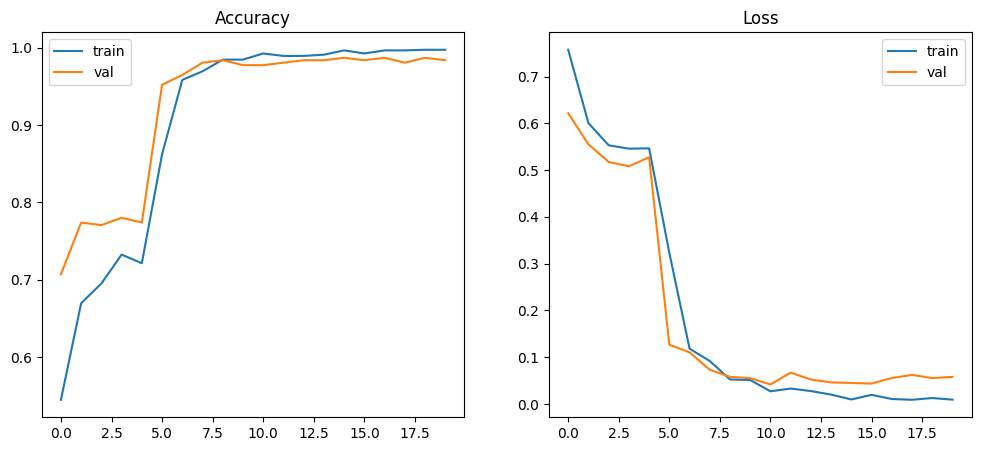

In [20]:
# =========================================================
# 14. PLOT
# =========================================================
epochs = range(len(all_history))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot([h["tr_acc"] for h in all_history], label="train")
plt.plot([h["va_acc"] for h in all_history], label="val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot([h["tr_loss"] for h in all_history], label="train")
plt.plot([h["va_loss"] for h in all_history], label="val")
plt.title("Loss")
plt.legend()

plt.show()

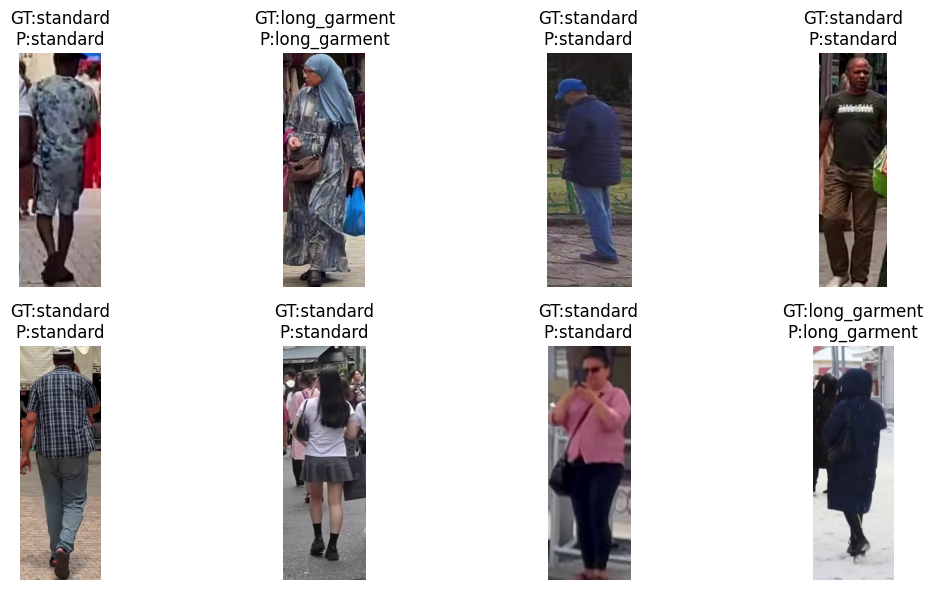

In [21]:
# =========================================================
# 15. INFERENCE TEST
# =========================================================
import random
from PIL import Image

model.eval()

samples = random.sample(val_idx, min(8, len(val_idx)))

plt.figure(figsize=(12,6))

for i, idx in enumerate(samples):
    path, label = full_dataset.samples[idx]
    img = Image.open(path).convert("RGB")

    x = val_tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x).argmax(1).item()

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(f"GT:{class_names[label]}\nP:{class_names[pred]}")
    plt.axis("off")

plt.tight_layout()
plt.show()